In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/omarashrafabdelhamid/exams-dataset1/June 2019 QP.pdf
/kaggle/input/datasets/omarashrafabdelhamid/exams-dataset1/June 2018 QP.pdf


In [3]:
!pip install -q \
langchain \
langchain-community \
langchain-huggingface \
langchain-text-splitters \
langchain-chroma \
chromadb \
sentence-transformers \
pymupdf \
pypdf \
reportlab \
streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 48.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 43.8 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 72.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 46.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 82.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 84.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.6/561.6 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 77.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.1 MB/s eta 0:00:

In [4]:
import langchain
import fitz
import pypdf
import chromadb
import sentence_transformers

print("Everything works!")

Everything works!


In [5]:
import os

folders = [
    "exams",
    "syllabus",
    "vector_db",
    "output"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created.")

Folders created.


In [6]:
from pathlib import Path

# Path to your Kaggle dataset
dataset_path = Path("/kaggle/input/datasets/omarashrafabdelhamid/exams-dataset1")

# Find all PDF files
pdf_files = sorted(dataset_path.rglob("*.pdf"))

print(f"Found {len(pdf_files)} PDF files:\n")

for pdf in pdf_files:
    print(pdf.name)

Found 2 PDF files:

June 2018 QP.pdf
June 2019 QP.pdf


In [7]:
import fitz  # PyMuPDF

pages = []

for pdf_path in pdf_files:
    doc = fitz.open(pdf_path)

    for page_num in range(len(doc)):
        page = doc.load_page(page_num)

        # Render page as high-quality image
        pix = page.get_pixmap(matrix=fitz.Matrix(2, 2))

        pages.append({
            "exam_name": pdf_path.name,
            "page_number": page_num + 1,
            "image": pix
        })

    doc.close()

print(f"Total pages loaded: {len(pages)}")

Total pages loaded: 30


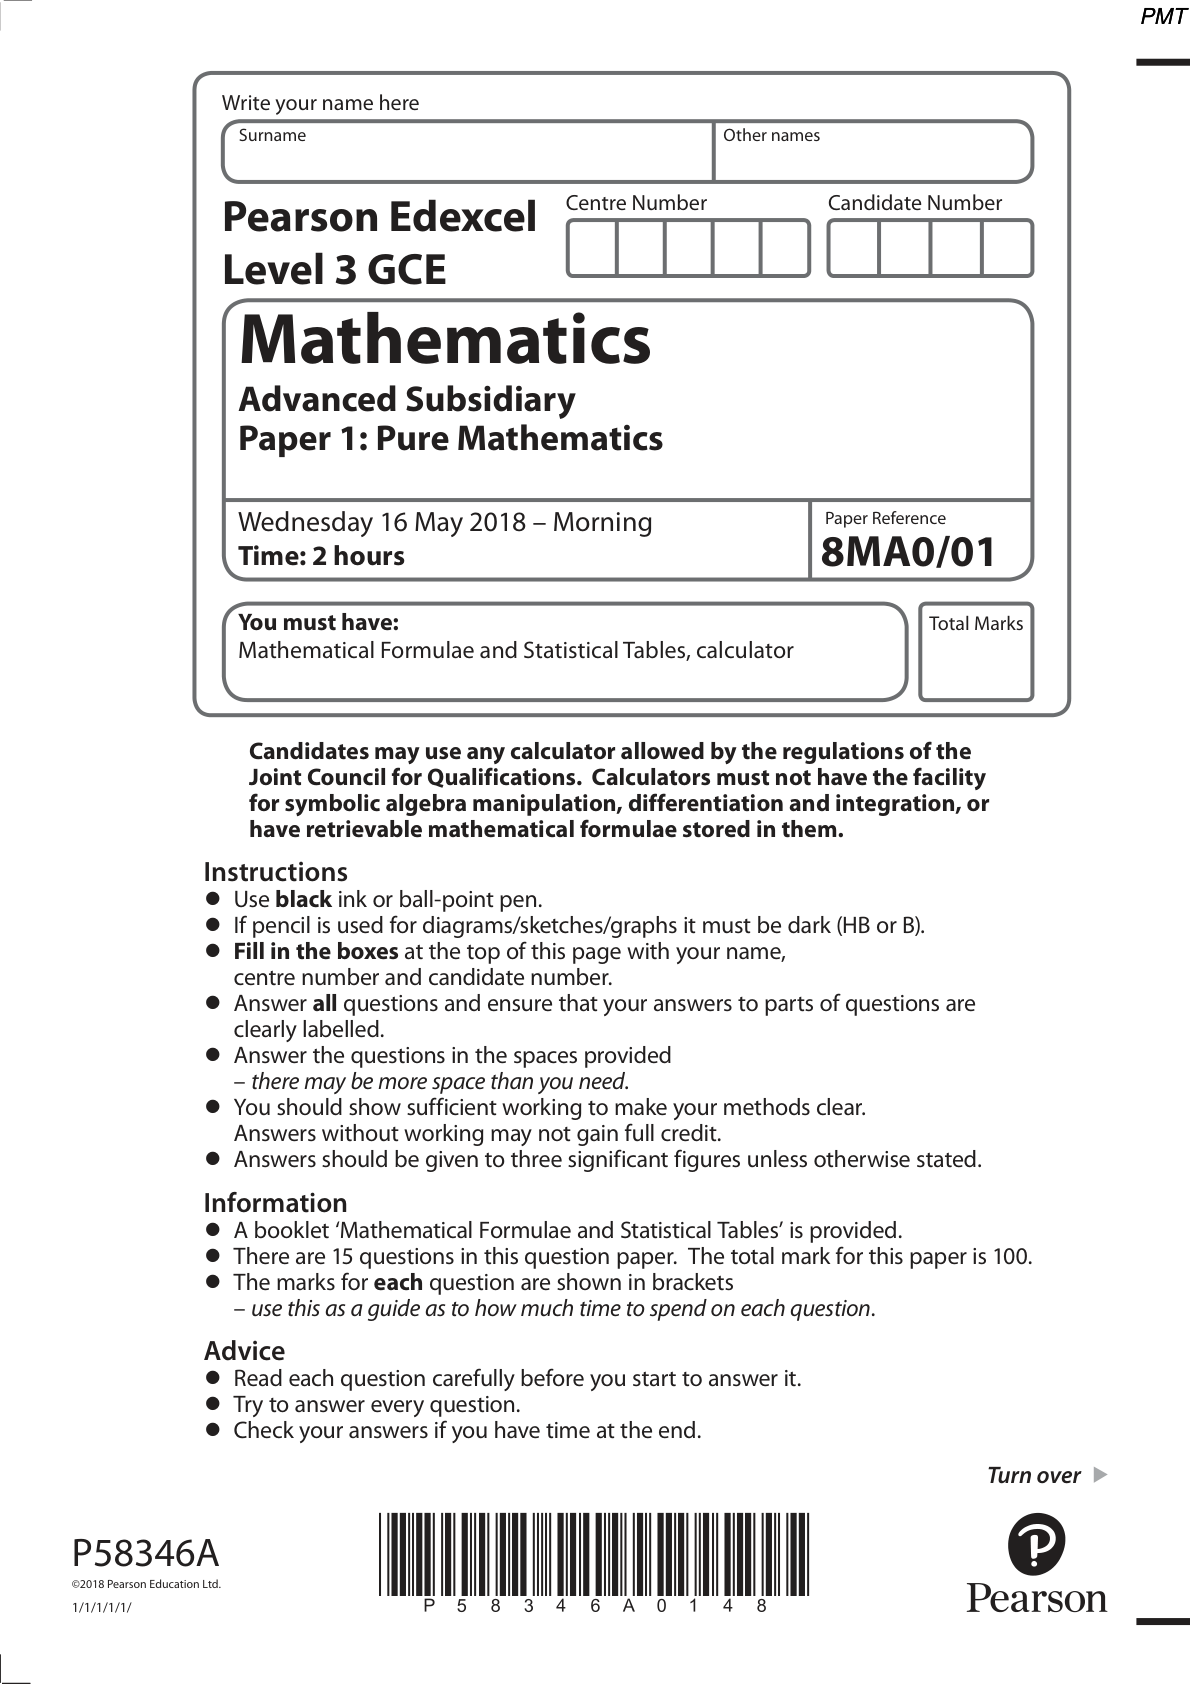

Exam: June 2018 QP.pdf
Page: 1


In [8]:
from PIL import Image

# Display the first page image
first_page = pages[0]["image"]

img = Image.frombytes(
    "RGB",
    [first_page.width, first_page.height],
    first_page.samples
)

display(img)

print("Exam:", pages[0]["exam_name"])
print("Page:", pages[0]["page_number"])

In [9]:
questions = []
question_id = 1

for page in pages:
    # Skip the cover page (Page 1)
    if page["page_number"] == 1:
        continue

    questions.append({
        "question_id": question_id,
        "exam_name": page["exam_name"],
        "page_number": page["page_number"],
        "question_number": page["page_number"] - 1,  # Page 2 -> Question 1
        "image": page["image"]
    })

    question_id += 1

print(f"Total Questions: {len(questions)}")

Total Questions: 28


In [10]:
print(questions[0]["exam_name"])
print("Question:", questions[0]["question_number"])
print("Page:", questions[0]["page_number"])

June 2018 QP.pdf
Question: 1
Page: 2


In [11]:
from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
)
import torch

In [12]:
MODEL_ID = "Qwen/Qwen2.5-VL-7B-Instruct"

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(MODEL_ID)

print("✅ Qwen2.5-VL loaded successfully!")

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Qwen2.5-VL loaded successfully!


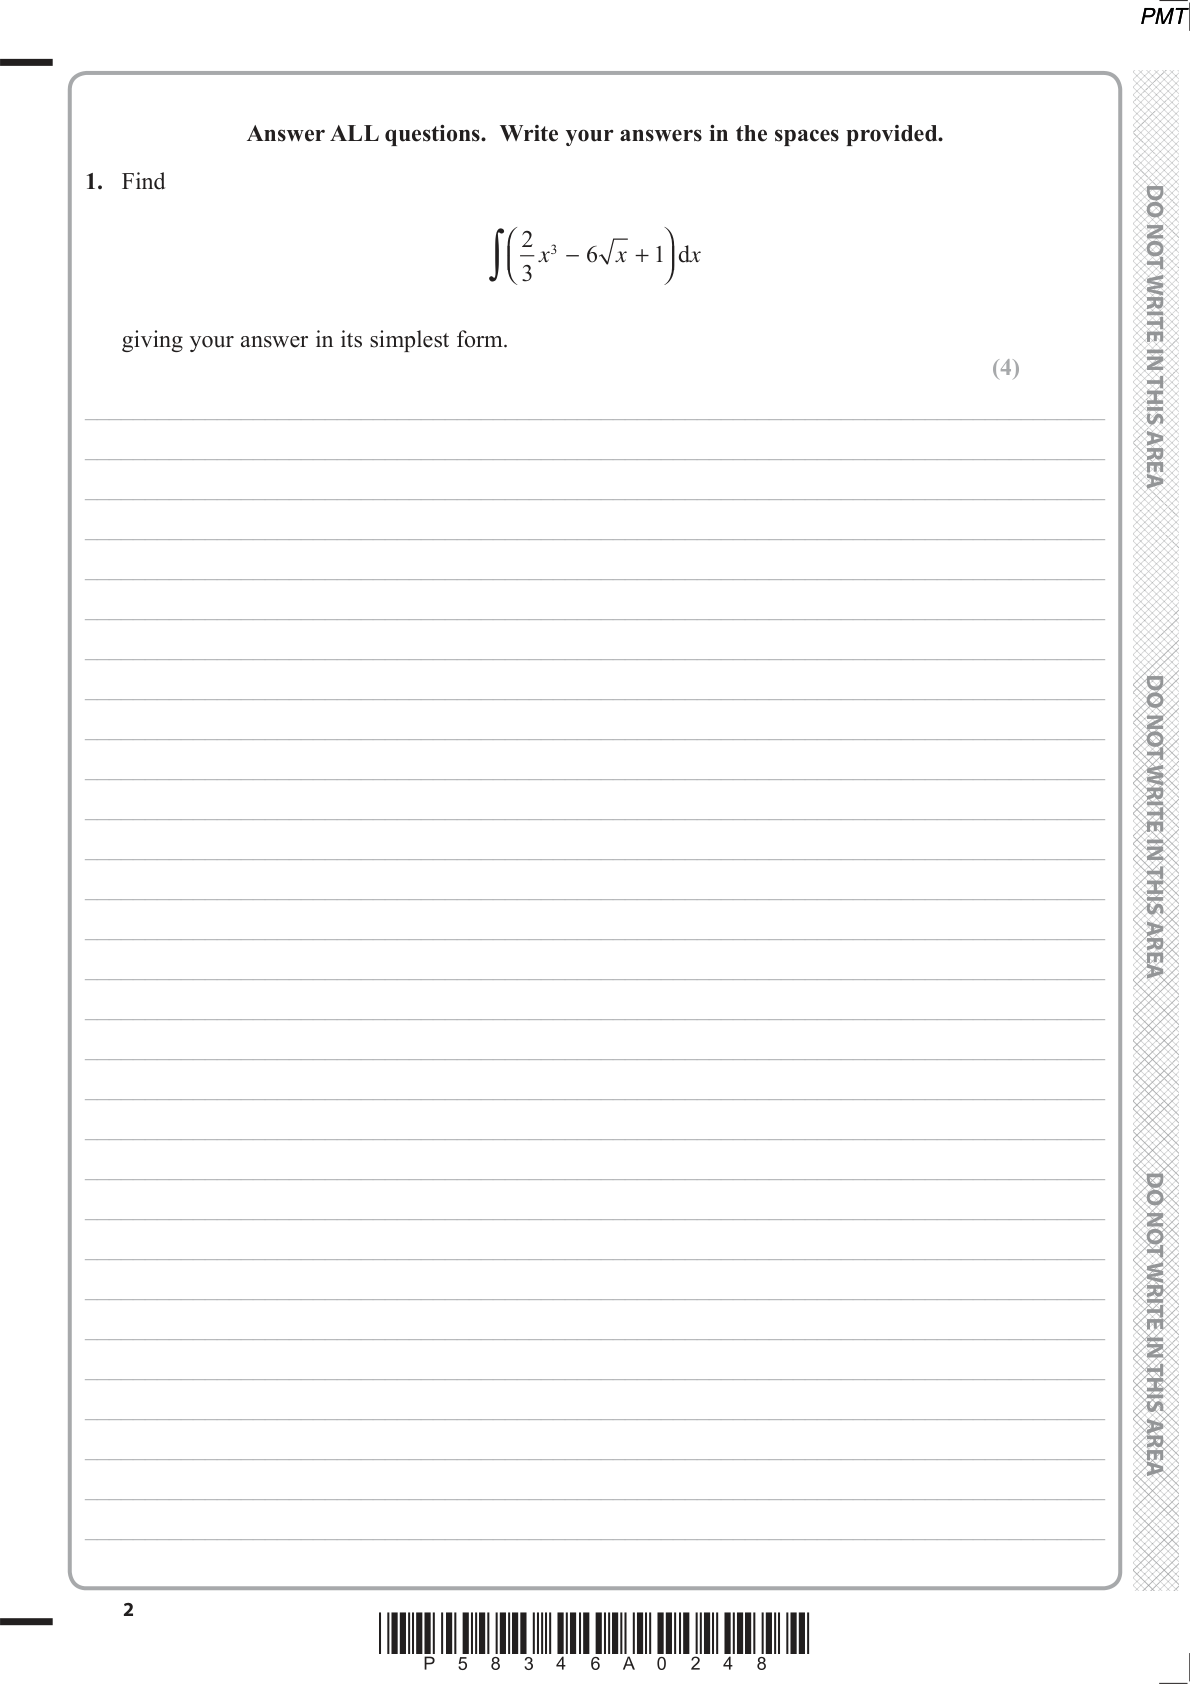

In [13]:
from PIL import Image

# Take the first question (Page 2)
pix = questions[0]["image"]

image = Image.frombytes(
    "RGB",
    [pix.width, pix.height],
    pix.samples
)

display(image)

In [14]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image,
            },
            {
                "type": "text",
                "text": "Read this exam question and explain briefly what topic it is about."
            },
        ],
    }
]

In [15]:
import transformers
print(transformers.__version__)

5.0.0


In [16]:
!pip install -q qwen-vl-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 54.8 MB/s eta 0:00:00:00:0100:01


In [17]:
from qwen_vl_utils import process_vision_info

# Prepare the prompt
text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

image_inputs, video_inputs = process_vision_info(messages)

inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)

inputs = inputs.to(model.device)

In [18]:
generated_ids = model.generate(
    **inputs,
    max_new_tokens=256
)

generated_ids_trimmed = [
    out_ids[len(in_ids):]
    for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]

response = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False,
)

description = response[0]

print(description)

This exam question is about integral calculus, specifically the process of finding the indefinite integral of a function. The function given is \(\left(\frac{2}{3}x^3 - 6\sqrt{x} + 1\right)\), and the task is to integrate it with respect to \(x\) and express the answer in its simplest form.


In [19]:
syllabus = """
Chapter 1: Functions
Chapter 2: Limits
Chapter 3: Differentiation
Chapter 4: Integration
Chapter 5: Vectors
Chapter 6: Trigonometry
Chapter 7: Coordinate Geometry
Chapter 8: Logarithms
Chapter 9: Binomial Expansion
Chapter 10: Proof
"""

print(syllabus)


Chapter 1: Functions
Chapter 2: Limits
Chapter 3: Differentiation
Chapter 4: Integration
Chapter 5: Vectors
Chapter 6: Trigonometry
Chapter 7: Coordinate Geometry
Chapter 8: Logarithms
Chapter 9: Binomial Expansion
Chapter 10: Proof



In [20]:
from langchain_core.documents import Document

doc = Document(page_content=syllabus)

print(doc)

page_content='
Chapter 1: Functions
Chapter 2: Limits
Chapter 3: Differentiation
Chapter 4: Integration
Chapter 5: Vectors
Chapter 6: Trigonometry
Chapter 7: Coordinate Geometry
Chapter 8: Logarithms
Chapter 9: Binomial Expansion
Chapter 10: Proof
'


In [21]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=20
)

documents = text_splitter.split_documents([doc])

print(f"Number of chunks: {len(documents)}")

for d in documents:
    print("-" * 30)
    print(d.page_content)

Number of chunks: 3
------------------------------
Chapter 1: Functions
Chapter 2: Limits
Chapter 3: Differentiation
Chapter 4: Integration
------------------------------
Chapter 5: Vectors
Chapter 6: Trigonometry
Chapter 7: Coordinate Geometry
Chapter 8: Logarithms
------------------------------
Chapter 9: Binomial Expansion
Chapter 10: Proof


In [22]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

/tmp/ipykernel_58/1893394799.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [23]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [24]:
!pip install -q faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 68.0 MB/s eta 0:00:00:00:0100:01


In [25]:
vector_db = FAISS.from_documents(
    documents=documents,
    embedding=embeddings
)

print("✅ Vector database created successfully!")

✅ Vector database created successfully!


In [26]:
retriever = vector_db.as_retriever(
    search_kwargs={"k": 2}
)

print("✅ Retriever created!")

✅ Retriever created!


In [27]:
query = "This question is about definite integration."

results = retriever.invoke(query)

for i, doc in enumerate(results, start=1):
    print(f"Result {i}")
    print(doc.page_content)
    print("-" * 40)

Result 1
Chapter 1: Functions
Chapter 2: Limits
Chapter 3: Differentiation
Chapter 4: Integration
----------------------------------------
Result 2
Chapter 9: Binomial Expansion
Chapter 10: Proof
----------------------------------------


In [28]:
# Take the first question
pix = questions[0]["image"]

image = Image.frombytes(
    "RGB",
    [pix.width, pix.height],
    pix.samples
)

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image,
            },
            {
                "type": "text",
                "text": """
You are an expert university instructor.

Look at this exam question.

Describe ONLY the mathematical topics and concepts being tested.

Rules:
- Do NOT solve the question.
- Do NOT mention chapter numbers.
- Keep the answer under 40 words.
"""
            },
        ],
    }
]

In [29]:
results = retriever.invoke(description)

print("Retrieved Chapters:\n")

for i, doc in enumerate(results, start=1):
    print(f"Result {i}:")
    print(doc.page_content)
    print("-" * 50)

Retrieved Chapters:

Result 1:
Chapter 1: Functions
Chapter 2: Limits
Chapter 3: Differentiation
Chapter 4: Integration
--------------------------------------------------
Result 2:
Chapter 9: Binomial Expansion
Chapter 10: Proof
--------------------------------------------------


In [30]:
#describe question

from PIL import Image as PILImage
def describe_question(question):
    pix = question["image"]

    image = PILImage.frombytes(
        "RGB",
        [pix.width, pix.height],
        pix.samples
    )

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image,
                },
                {
                    "type": "text",
                    "text": """
You are an expert university instructor.

Look at this exam question.

Describe ONLY the mathematical topics and concepts being tested.

Rules:
- Do NOT solve the question.
- Do NOT mention chapter numbers.
- Keep the answer under 40 words.
"""
                },
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = processor(
        text=[text],
        images=[image],
        padding=True,
        return_tensors="pt",
    ).to(model.device)

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=80
    )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]

    response = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True
    )[0]

    return response

In [31]:
description = describe_question(questions[0])

print(description)

Integration, power rule, square root function, polynomial functions.


In [32]:
#retrieve chapters functions
def retrieve_chapters(description, k=2):
    docs = retriever.invoke(description)

    chapters = []

    for doc in docs:
        chapters.append(doc.page_content)

    return chapters

In [33]:
description = describe_question(questions[0])

chapters = retrieve_chapters(description)

print("Description:")
print(description)

print("\nRetrieved Chapters:")
for chapter in chapters:
    print("-", chapter)

Description:
Integration, power rule, square root function, polynomial functions.

Retrieved Chapters:
- Chapter 1: Functions
Chapter 2: Limits
Chapter 3: Differentiation
Chapter 4: Integration
- Chapter 9: Binomial Expansion
Chapter 10: Proof


In [34]:
from pydantic import BaseModel, Field

In [35]:
class QuestionClassification(BaseModel):
    chapter: str = Field(description="The best matching syllabus chapter")
    confidence: float = Field(description="Confidence score between 0 and 1")
    reason: str = Field(description="Short explanation for the classification")

In [36]:
from langchain_core.output_parsers import PydanticOutputParser

parser = PydanticOutputParser(
    pydantic_object=QuestionClassification
)

In [37]:
format_instructions = parser.get_format_instructions()

print(format_instructions)

The output should be formatted as a JSON instance that conforms to the JSON schema below.

As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.

Here is the output schema:
```
{"properties": {"chapter": {"description": "The best matching syllabus chapter", "title": "Chapter", "type": "string"}, "confidence": {"description": "Confidence score between 0 and 1", "title": "Confidence", "type": "number"}, "reason": {"description": "Short explanation for the classification", "title": "Reason", "type": "string"}}, "required": ["chapter", "confidence", "reason"]}
```


In [38]:
#classify question function
def classify_question(question):
    # Step 1: Describe the question
    description = describe_question(question)

    # Step 2: Retrieve relevant chapters
    chapters = retrieve_chapters(description)

    # Combine retrieved chapters into context
    chapter_context = "\n".join(chapters)

    # Step 3: Prepare image
    pix = question["image"]

    image = PILImage.frombytes(
        "RGB",
        [pix.width, pix.height],
        pix.samples
    )

    # Step 4: Build prompt
    prompt = f"""
You are an expert exam classifier.

The syllabus contains these chapters:

{chapter_context}

Based ONLY on these chapters, classify the exam question into the SINGLE best chapter.

{format_instructions}
"""

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image,
                },
                {
                    "type": "text",
                    "text": prompt,
                },
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = processor(
        text=[text],
        images=[image],
        padding=True,
        return_tensors="pt",
    ).to(model.device)

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=150
    )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]

    response = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True
    )[0]

    return response

In [39]:
response = classify_question(questions[0])

print(response)

```json
{
  "chapter": "Chapter 4",
  "confidence": 1,
  "reason": "The question involves finding the integral of a function, which is a topic covered in Chapter 4: Integration."
}
```


In [216]:
import re
import json

def parse_classification(response):
    cleaned = re.sub(r"```json|```", "", response).strip()

    # Remove LaTeX delimiters
    cleaned = cleaned.replace("\\(", "")
    cleaned = cleaned.replace("\\)", "")

    try:
        data = json.loads(cleaned)
        return QuestionClassification(**data)

    except Exception:
        print("Failed to parse:")
        print(cleaned)
        raise

In [41]:
result = parse_classification(response)

print(result)

chapter='Chapter 4' confidence=1.0 reason='The question involves finding the integral of a function, which is a topic covered in Chapter 4: Integration.'


In [42]:
from tqdm import tqdm

def process_all_questions(questions):
    results = []

    for question in tqdm(questions, desc="Classifying Questions"):
        try:
            response = classify_question(question)
            result = parse_classification(response)

            results.append({
                "question_number": question["question_number"],
                "exam_name": question["exam_name"],
                "chapter": result.chapter,
                "confidence": result.confidence,
                "reason": result.reason,
                "image": question["image"]
            })

        except Exception as e:
            print(f"Error processing Question {question['question_number']}: {e}")

            results.append({
    "question_number": question["question_number"],
    "page_number": question["page_number"],
    "exam_name": question["exam_name"],
    "chapter": result.chapter,
    "confidence": result.confidence,
    "reason": result.reason,
    "image": question["image"],
    "description": description
})

    return results

In [43]:
sample_results = process_all_questions(questions[:3])

Classifying Questions: 100%|██████████| 3/3 [00:51<00:00, 17.16s/it]


In [44]:
for r in sample_results:
    print("=" * 50)
    print(f"Question: {r['question_number']}")
    print(f"Chapter: {r['chapter']}")
    print(f"Confidence: {r['confidence']}")
    print(f"Reason: {r['reason']}")

Question: 1
Chapter: Chapter 4
Confidence: 1.0
Reason: The question involves finding the integral of a function, which is a topic covered in Chapter 4: Integration.
Question: 2
Chapter: Chapter 10
Confidence: 0.95
Reason: The question involves proving a statement using algebraic manipulation, which aligns with the concept of proof in Chapter 10.
Question: 3
Chapter: Chapter 5: Vectors
Confidence: 1.0
Reason: The question involves vector operations, specifically finding the difference between two position vectors and calculating the magnitude of the resulting vector.


In [45]:
from collections import defaultdict

def group_by_chapter(results):
    grouped = defaultdict(list)

    for item in results:
        grouped[item["chapter"]].append(item)

    return grouped

In [46]:
grouped_questions = group_by_chapter(sample_results)

for chapter, questions in grouped_questions.items():
    print(f"\n{chapter}")
    print("-" * 40)

    for q in questions:
        print(f"Question {q['question_number']}")


Chapter 4
----------------------------------------
Question 1

Chapter 10
----------------------------------------
Question 2

Chapter 5: Vectors
----------------------------------------
Question 3


In [47]:
!pip install -q reportlab

In [48]:
from reportlab.platypus import SimpleDocTemplate, Paragraph
from reportlab.lib.styles import getSampleStyleSheet

styles = getSampleStyleSheet()

doc = SimpleDocTemplate("Question_Bank.pdf")

story = []

story.append(Paragraph("<b>Question Bank</b>", styles["Title"]))
story.append(Paragraph("Generated by AI Question Classifier", styles["Normal"]))

doc.build(story)

print("✅ PDF created successfully!")

✅ PDF created successfully!


In [49]:
import os

os.makedirs("temp_images", exist_ok=True)

pix = sample_results[0]["image"]

image_path = "temp_images/question1.png"

pix.save(image_path)

print("Saved:", image_path)

Saved: temp_images/question1.png


In [52]:
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Image as RLImage,
    Spacer,
)
from reportlab.lib.styles import getSampleStyleSheet

styles = getSampleStyleSheet()

doc = SimpleDocTemplate("Question_Bank_With_Image.pdf")

story = []

story.append(Paragraph("<b>Question Bank</b>", styles["Title"]))
story.append(Spacer(1, 20))

story.append(Paragraph("<b>Chapter 4</b>", styles["Heading1"]))
story.append(Paragraph("Question 1", styles["Heading2"]))

img = get_scaled_image(image_path)

story.append(img)

doc.build(story)

print("✅ PDF generated!")

✅ PDF generated!


In [215]:
#pdf helper function
from reportlab.platypus import Image as RLImage
from reportlab.lib.units import inch

def get_scaled_image(path, max_width=6.5 * inch, max_height=9 * inch):
    img = RLImage(path)

    width = img.imageWidth
    height = img.imageHeight

    scale = min(max_width / width, max_height / height)

    img.drawWidth = width * scale
    img.drawHeight = height * scale

    return img

In [234]:
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    PageBreak,
)
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.enums import TA_CENTER
from reportlab.lib.colors import darkblue
from reportlab.lib.units import inch
from copy import deepcopy
from pathlib import Path
import re

styles = getSampleStyleSheet()

# Create custom centered chapter style
chapter_style = deepcopy(styles["Heading1"])
chapter_style.alignment = TA_CENTER
chapter_style.textColor = darkblue
chapter_style.spaceAfter = 20
chapter_style.spaceBefore = 20


def generate_question_bank(grouped_questions, output_file="Question_Bank.pdf"):

    Path("temp_images").mkdir(exist_ok=True)

    doc = SimpleDocTemplate(output_file)

    story = []

    total_questions = sum(len(v) for v in grouped_questions.values())
    total_chapters = len(grouped_questions)

    # ---------------- Cover Page ---------------- #

    story.append(Paragraph("AI-Powered Question Bank", styles["Title"]))
    story.append(Spacer(1, 25))

    story.append(
        Paragraph(
            "Generated Automatically using Vision LLM + RAG",
            styles["Heading2"]
        )
    )

    story.append(Spacer(1, 35))

    story.append(
        Paragraph(f"<b>Total Chapters:</b> {total_chapters}", styles["Normal"])
    )

    story.append(
        Paragraph(f"<b>Total Questions:</b> {total_questions}", styles["Normal"])
    )

    story.append(PageBreak())

    chapters = list(grouped_questions.keys())

    for index, chapter in enumerate(chapters):

        # Remove numbering like "Chapter 1:"
        clean_chapter = re.sub(
            r"^\s*Chapter\s*\d+\s*:\s*",
            "",
            chapter,
            flags=re.IGNORECASE
        )

        story.append(
            Paragraph(clean_chapter.upper(), chapter_style)
        )

        story.append(Spacer(1, 15))

        for question in grouped_questions[chapter]:

            # Show source exam
            story.append(
                Paragraph(
                    f"<b>Source:</b> {question['exam_name']}",
                    styles["Normal"]
                )
            )

            story.append(
                Paragraph(
                    f"<b>Question {question['question_number']}</b>",
                    styles["Heading2"]
                )
            )

            story.append(Spacer(1, 8))

            image_path = (
                f"temp_images/"
                f"{clean_chapter.replace(':','').replace('/','-')}_{question['question_number']}.png"
            )

            question["image"].save(image_path)

            img = get_scaled_image(image_path)

            story.append(img)

            story.append(Spacer(1, 20))

        # Only add a page break if this isn't the last chapter
        if index != len(chapters) - 1:
            story.append(PageBreak())

    doc.build(story)

    print(f"✅ Saved to {output_file}")

    return output_file

Classifying Questions: 100%|██████████| 29/29 [09:17<00:00, 19.21s/it]


✅ Saved to Question_Bank.pdf
Output PDF: Question_Bank.pdf
Exists: True


Classifying Questions:  92%|█████████▏| 12/13 [03:43<00:19, 19.25s/it]

Failed to parse:
{
  "chapter": "Chapter 8: Logarithms",
  "confidence": 0.9,
  "reason": "The question involves logarithmic functions and their properties, specifically the relationship between  \log_{10}V  and  t , which is a key concept in Chapter 8."
}
Error processing Question 12: Invalid \escape: line 4 column 119 (char 179)


Classifying Questions: 100%|██████████| 13/13 [04:03<00:00, 18.72s/it]


✅ Saved to Question_Bank.pdf
Output PDF: Question_Bank.pdf
Exists: True
INFO:     196.131.215.158:0 - "POST /generate HTTP/1.1" 200 OK


Classifying Questions:   0%|          | 0/15 [00:00<?, ?it/s]

In [54]:
generate_question_bank(grouped_questions)

✅ Saved to Question_Bank.pdf


In [55]:
from langchain_core.runnables import RunnableLambda

In [56]:
describe_chain = RunnableLambda(describe_question)

retrieve_chain = RunnableLambda(retrieve_chapters)

parse_chain = RunnableLambda(parse_classification)

In [57]:
description = describe_chain.invoke(questions[0])

print(description)

Vector subtraction, magnitude of a vector, simplifying surds.


In [58]:
print(Image)

<class 'reportlab.platypus.flowables.Image'>


In [59]:
import inspect
print(inspect.getsource(describe_question))

def describe_question(question):
    pix = question["image"]

    image = PILImage.frombytes(
        "RGB",
        [pix.width, pix.height],
        pix.samples
    )

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image,
                },
                {
                    "type": "text",
                    "text": """
You are an expert university instructor.

Look at this exam question.

Describe ONLY the mathematical topics and concepts being tested.

Rules:
- Do NOT solve the question.
- Do NOT mention chapter numbers.
- Keep the answer under 40 words.
"""
                },
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = processor(
        text=[text],
        images=[image],
        padding=True,
        return_tensors="pt",
    ).to(mod

In [60]:
print(PILImage)
print(hasattr(PILImage, "frombytes"))

<module 'PIL.Image' from '/usr/local/lib/python3.12/dist-packages/PIL/Image.py'>
True


In [61]:
description = describe_question(questions[0])
print(description)

Vector subtraction, magnitude of a vector, simplifying surds.


In [62]:
from langchain_core.runnables import RunnableLambda

def classify_pipeline(question):
    response = classify_question(question)
    return parse_classification(response)

classification_chain = RunnableLambda(classify_pipeline)

In [63]:
result = classification_chain.invoke(questions[0])

print(result)

chapter='Chapter 5: Vectors' confidence=1.0 reason='The question involves vector operations, specifically finding the difference between two position vectors and calculating the magnitude of the resulting vector.'


In [64]:
!pip install fastapi uvicorn pyngrok nest-asyncio python-multipart

In [65]:
!pip install -q fastapi uvicorn pyngrok nest-asyncio python-multipart

In [66]:
from fastapi import FastAPI, Request, HTTPException
import uvicorn
import threading
import socket
import time
from pyngrok import ngrok, conf

In [ ]:
import os
NGROK_TOKEN = os.environ.get("NGROK_TOKEN", "")

In [238]:
app = FastAPI()

@app.get("/")
def home():
    return {"status": "running"}

In [239]:
from fastapi import FastAPI, UploadFile, File, Form, HTTPException
from fastapi.responses import FileResponse
from pathlib import Path
import tempfile
import fitz
import threading
import uuid
import traceback

app = FastAPI()

jobs = {}  # job_id -> {"status": "processing" | "done" | "error", "output_path": str, "error": str}


@app.get("/")
def home():
    return {"status": "running"}


@app.get("/ping")
def ping():
    return {"message": "pong"}


def run_job(job_id: str, pdf_files: list, syllabus: str):
    """Runs the heavy classification + PDF generation in its own thread,
    so it never blocks the FastAPI event loop / the ngrok connection."""
    try:
        pages = []
        for pdf_path in pdf_files:
            doc = fitz.open(pdf_path)
            for page_num in range(len(doc)):
                page = doc.load_page(page_num)
                pix = page.get_pixmap(matrix=fitz.Matrix(2, 2))
                pages.append({
                    "exam_name": pdf_path.name,
                    "page_number": page_num + 1,
                    "image": pix
                })
            doc.close()

        questions = []
        question_id = 1
        for page in pages:
            if page["page_number"] == 1:
                continue
            questions.append({
                "question_id": question_id,
                "exam_name": page["exam_name"],
                "page_number": page["page_number"],
                "question_number": page["page_number"] - 1,
                "image": page["image"]
            })
            question_id += 1

        processed_questions = process_all_questions(questions)
        grouped_questions = group_by_chapter(processed_questions)

        Path("job_outputs").mkdir(exist_ok=True)
        output_path = f"job_outputs/{job_id}.pdf"
        generate_question_bank(grouped_questions, output_file=output_path)

        jobs[job_id]["status"] = "done"
        jobs[job_id]["output_path"] = output_path

    except Exception as e:
        jobs[job_id]["status"] = "error"
        jobs[job_id]["error"] = str(e)
        print(f"Job {job_id} failed:")
        traceback.print_exc()


@app.post("/generate")
async def generate(
    syllabus: str = Form(...),
    files: list[UploadFile] = File(...)
):
    job_id = str(uuid.uuid4())
    temp_dir = Path(tempfile.mkdtemp())
    pdf_files = []

    for file in files:
        file_path = temp_dir / file.filename
        with open(file_path, "wb") as f:
            f.write(await file.read())
        pdf_files.append(file_path)

    jobs[job_id] = {"status": "processing", "output_path": None, "error": None}

    thread = threading.Thread(
        target=run_job,
        args=(job_id, pdf_files, syllabus),
        daemon=True
    )
    thread.start()

    return {"job_id": job_id, "status": "processing"}


@app.get("/status/{job_id}")
def get_status(job_id: str):
    job = jobs.get(job_id)
    if job is None:
        raise HTTPException(status_code=404, detail="Job not found")
    return {"job_id": job_id, "status": job["status"], "error": job["error"]}


@app.get("/result/{job_id}")
def get_result(job_id: str):
    job = jobs.get(job_id)
    if job is None:
        raise HTTPException(status_code=404, detail="Job not found")
    if job["status"] != "done":
        raise HTTPException(status_code=400, detail=f"Job status is '{job['status']}'")
    return FileResponse(
        job["output_path"],
        media_type="application/pdf",
        filename="Question_Bank.pdf"
    )

In [240]:
ngrok.kill()
def free_port():
    s = socket.socket()
    s.bind(("", 0))
    port = s.getsockname()[1]
    s.close()
    return port



port = free_port()

conf.get_default().auth_token = NGROK_TOKEN

public_url = ngrok.connect(port).public_url

print(public_url)

https://dramatic-art-feed.ngrok-free.dev


In [241]:
def run():
    uvicorn.run(app, host="0.0.0.0", port=port)

threading.Thread(target=run, daemon=True).start()

time.sleep(2)

INFO:     Started server process [58]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:40955 (Press CTRL+C to quit)


In [242]:
import requests

requests.get(f"http://127.0.0.1:{port}/ping").json()

INFO:     127.0.0.1:32970 - "GET /ping HTTP/1.1" 200 OK


{'message': 'pong'}

In [243]:
import requests

response = requests.post(
    public_url + "/generate",
    headers={"ngrok-skip-browser-warning": "true"},
    json={"syllabus": "test"}
)

print(response.status_code)
print(response.text)

INFO:     34.182.246.76:0 - "POST /generate HTTP/1.1" 422 Unprocessable Entity
422
{"detail":[{"type":"missing","loc":["body","syllabus"],"msg":"Field required","input":null},{"type":"missing","loc":["body","files"],"msg":"Field required","input":null}]}


In [244]:
print(public_url)
print(port)

https://dramatic-art-feed.ngrok-free.dev
40955


In [245]:

conf.get_default().auth_token = NGROK_TOKEN

public_url = ngrok.connect(port).public_url

print(public_url)

https://dramatic-art-feed.ngrok-free.dev
INFO:     196.131.215.158:0 - "POST /generate HTTP/1.1" 200 OK


Classifying Questions:   0%|          | 0/29 [00:00<?, ?it/s]

INFO:     196.131.215.158:0 - "GET /status/0c3dfd3b-4f29-4013-810e-d5324469d11b HTTP/1.1" 200 OK
INFO:     196.131.215.158:0 - "GET /status/0c3dfd3b-4f29-4013-810e-d5324469d11b HTTP/1.1" 200 OK
INFO:     196.131.215.158:0 - "GET /status/0c3dfd3b-4f29-4013-810e-d5324469d11b HTTP/1.1" 200 OK
INFO:     196.131.215.158:0 - "GET /status/0c3dfd3b-4f29-4013-810e-d5324469d11b HTTP/1.1" 200 OK


Classifying Questions:   3%|▎         | 1/29 [00:17<08:03, 17.25s/it]

INFO:     196.131.215.158:0 - "GET /status/0c3dfd3b-4f29-4013-810e-d5324469d11b HTTP/1.1" 200 OK
INFO:     196.131.215.158:0 - "GET /status/0c3dfd3b-4f29-4013-810e-d5324469d11b HTTP/1.1" 200 OK
INFO:     196.131.215.158:0 - "GET /status/0c3dfd3b-4f29-4013-810e-d5324469d11b HTTP/1.1" 200 OK


...

INFO:     196.131.215.158:0 - "GET /status/0c3dfd3b-4f29-4013-810e-d5324469d11b HTTP/1.1" 200 OK
INFO:     196.131.215.158:0 - "GET /status/0c3dfd3b-4f29-4013-810e-d5324469d11b HTTP/1.1" 200 OK
INFO:     196.131.215.158:0 - "GET /status/0c3dfd3b-4f29-4013-810e-d5324469d11b HTTP/1.1" 200 OK


Classifying Questions:  97%|█████████▋| 28/29 [08:58<00:19, 19.34s/it]

INFO:     196.131.215.158:0 - "GET /status/0c3dfd3b-4f29-4013-810e-d5324469d11b HTTP/1.1" 200 OK
INFO:     196.131.215.158:0 - "GET /status/0c3dfd3b-4f29-4013-810e-d5324469d11b HTTP/1.1" 200 OK
INFO:     196.131.215.158:0 - "GET /status/0c3dfd3b-4f29-4013-810e-d5324469d11b HTTP/1.1" 200 OK
INFO:     196.131.215.158:0 - "GET /status/0c3dfd3b-4f29-4013-810e-d5324469d11b HTTP/1.1" 200 OK


Classifying Questions: 100%|██████████| 29/29 [09:17<00:00, 19.22s/it]


INFO:     196.131.215.158:0 - "GET /status/0c3dfd3b-4f29-4013-810e-d5324469d11b HTTP/1.1" 200 OK
✅ Saved to job_outputs/0c3dfd3b-4f29-4013-810e-d5324469d11b.pdf
INFO:     196.131.215.158:0 - "GET /status/0c3dfd3b-4f29-4013-810e-d5324469d11b HTTP/1.1" 200 OK
INFO:     196.131.215.158:0 - "GET /result/0c3dfd3b-4f29-4013-810e-d5324469d11b HTTP/1.1" 200 OK
